<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/QuantumMRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-ibm-runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-05-02 07:33:23,410: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for the largest available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-05-02 07:33:24,008: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-02 07:33:25,716: Using instance: open-instance, plan: open


Target Acquired: ibm_marrakesh (Accessing entire 156-qubit array)
Encoding Global Excitation across all subatomic nodes...
Transpiling 156-Qubit MRI for physical topology of ibm_marrakesh...
Deploying Macroscopic MRI Scan to ibm_marrakesh queue... (WAITING IN LINE)
Job ID: d7qqhhnljm6s73b9iu3g
Macroscopic Hardware Scan successfully retrieved from Base Reality!


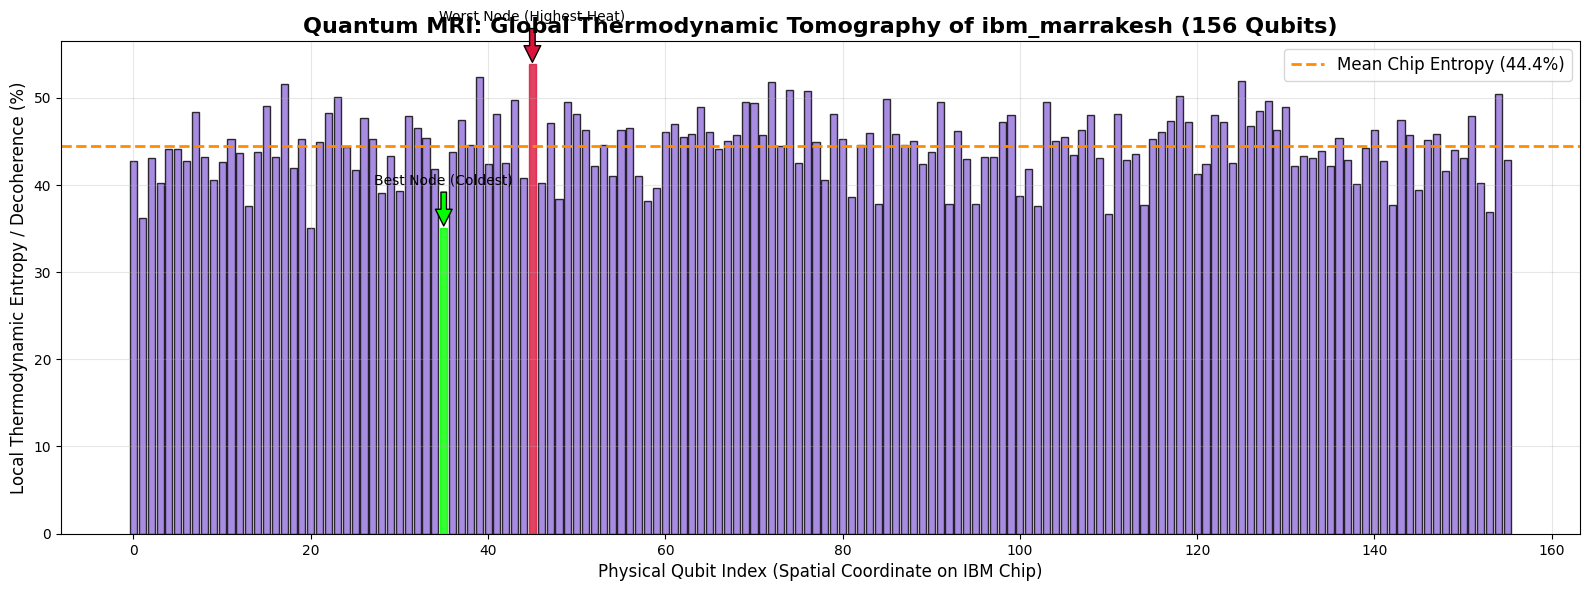


=== MRI SCAN COMPLETE ===
You successfully mapped the physical degradation of 156 subatomic nodes simultaneously.
The Coldest (most mathematically perfect) spot on the chip is Qubit 35 (35.0% Noise).
The Hottest (most physically degraded) spot is Qubit 45 (53.8% Noise).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here"

QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for the largest available physical QPU...")
# We request a heavy-hex processor (at least 127 qubits, up to 156)
backend = service.least_busy(simulator=False, min_num_qubits=127, operational=True)
num_qubits = backend.num_qubits
print(f"Target Acquired: {backend.name} (Accessing entire {num_qubits}-qubit array)")
shots = 2000

# ==========================================
# 1. BUILD THE GLOBAL MRI CIRCUIT (Hahn Echo Sequence)
# ==========================================
qr = QuantumRegister(num_qubits, 'node')
cr = ClassicalRegister(num_qubits, 'scan')
qc_mri = QuantumCircuit(qr, cr)

# STEP 1: Global Excitation
# We push the entire macroscopic chip into a high-energy superposition
print("Encoding Global Excitation across all subatomic nodes...")
qc_mri.rx(np.pi / 2, qr)

# STEP 2: The Thermodynamic Stress Test
# We let the physical environment (heat, crosstalk) corrupt the quantum states
delay_time = 10000 # dt (Device Time Steps)
for i in range(num_qubits):
    qc_mri.delay(delay_time, qr[i], unit='dt')

# STEP 3: The Geometric Mirror (Spin Echo)
# We flip the geometry to cancel out static noise, leaving ONLY the true thermodynamic friction
qc_mri.x(qr)

# Step 4: Second Thermodynamic Delay
for i in range(num_qubits):
    qc_mri.delay(delay_time, qr[i], unit='dt')

# STEP 5: Uncompute and Measure
# In a perfect universe, the state perfectly returns to '0'.
# Any '1' recorded is localized physical hardware damage.
qc_mri.rx(np.pi / 2, qr)
qc_mri.measure(qr, cr)

# ==========================================
# 2. EXECUTE THE MACROSCOPIC SCAN
# ==========================================
print(f"Transpiling 156-Qubit MRI for physical topology of {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target, scheduling_method='alap')
isa_qc_mri = pm.run(qc_mri)

print(f"Deploying Macroscopic MRI Scan to {backend.name} queue... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_mri], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
counts = result[0].data.scan.get_counts()
print("Macroscopic Hardware Scan successfully retrieved from Base Reality!")

# ==========================================
# 3. PARSE THE LOCAL ENTROPY INDEX
# ==========================================
# We calculate the exact thermodynamic friction experienced by EVERY single qubit.
qubit_entropy = np.zeros(num_qubits)

for bitstring, count in counts.items():
    clean_bits = bitstring.replace(" ", "")
    for i in range(num_qubits):
        # Qiskit reads strings right-to-left.
        # State '1' means the physical environment destroyed the mathematical coherence.
        if clean_bits[num_qubits - 1 - i] == '1':
            qubit_entropy[i] += count

# Convert to percentage
qubit_entropy = (qubit_entropy / shots) * 100

# Calculate Chip-Wide Statistics
mean_entropy = np.mean(qubit_entropy)
max_entropy_qubit = np.argmax(qubit_entropy)
min_entropy_qubit = np.argmin(qubit_entropy)

# ==========================================
# 4. VISUALIZE THE QPU MRI (Topological Entropy Map)
# ==========================================
fig, ax = plt.subplots(figsize=(16, 6))

# Plot the entropy footprint of every physical node
bars = ax.bar(range(num_qubits), qubit_entropy, color='mediumpurple', edgecolor='black', alpha=0.8)

# Highlight the worst and best qubits on the chip
bars[max_entropy_qubit].set_color('crimson')
bars[min_entropy_qubit].set_color('lime')

ax.set_title(f"Quantum MRI: Global Thermodynamic Tomography of {backend.name} ({num_qubits} Qubits)", fontsize=16, fontweight='bold')
ax.set_xlabel("Physical Qubit Index (Spatial Coordinate on IBM Chip)", fontsize=12)
ax.set_ylabel("Local Thermodynamic Entropy / Decoherence (%)", fontsize=12)

# Add horizontal baseline for average chip noise
ax.axhline(y=mean_entropy, color='darkorange', linestyle='--', linewidth=2, label=f"Mean Chip Entropy ({mean_entropy:.1f}%)")

ax.annotate(f'Worst Node (Highest Heat)', xy=(max_entropy_qubit, qubit_entropy[max_entropy_qubit]),
            xytext=(max_entropy_qubit, qubit_entropy[max_entropy_qubit] + 5),
            arrowprops=dict(facecolor='crimson', shrink=0.05), fontsize=10, ha='center')

ax.annotate(f'Best Node (Coldest)', xy=(min_entropy_qubit, qubit_entropy[min_entropy_qubit]),
            xytext=(min_entropy_qubit, qubit_entropy[min_entropy_qubit] + 5),
            arrowprops=dict(facecolor='lime', shrink=0.05), fontsize=10, ha='center')

ax.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== MRI SCAN COMPLETE ===")
print(f"You successfully mapped the physical degradation of {num_qubits} subatomic nodes simultaneously.")
print(f"The Coldest (most mathematically perfect) spot on the chip is Qubit {min_entropy_qubit} ({qubit_entropy[min_entropy_qubit]:.1f}% Noise).")
print(f"The Hottest (most physically degraded) spot is Qubit {max_entropy_qubit} ({qubit_entropy[max_entropy_qubit]:.1f}% Noise).")